In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from Tracer.windfield import WindField
from scipy.interpolate import interp1d
import joblib

In [4]:
ds = xr.open_dataset("streamwise_slice_300m.nc")
print(ds)

<xarray.Dataset> Size: 177MB
Dimensions:  (t: 901, x: 101, z: 81)
Coordinates:
  * t        (t) float64 7kB 0.0 1.0 2.0 3.0 4.0 ... 897.0 898.0 899.0 900.0
  * x        (x) float64 808B 0.0 10.0 20.0 30.0 ... 970.0 980.0 990.0 1e+03
  * z        (z) float64 648B 2.5 12.5 22.5 32.5 ... 772.5 782.5 792.5 802.5
Data variables:
    u        (t, x, z) float64 59MB ...
    v        (t, x, z) float64 59MB ...
    w        (t, x, z) float64 59MB ...
Attributes:
    description:  Streamwise slice at y=300.00000000000006m
    utau:         0.46325


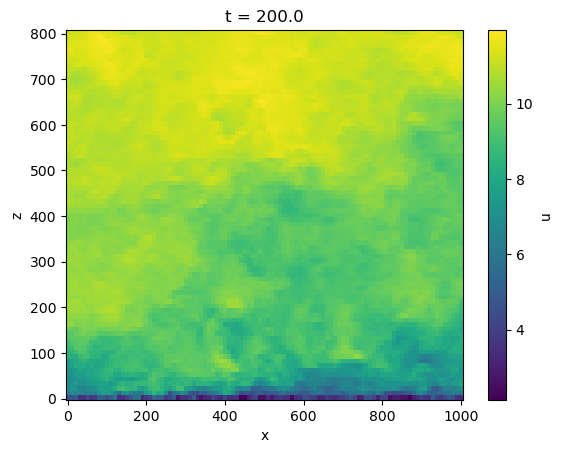

In [5]:
ds.isel(t=200)['u'].plot(x="x", y="z", cmap="viridis")

In [6]:
def plot_pod_energy(S, threshold=0.8):
    # 1. Calculate Eigenvalues (Energy)
    lambdas = S**2
    
    # 2. Calculate Individual and Cumulative Energy Fraction
    energy_fraction = lambdas / np.sum(lambdas)
    cumulative_energy = np.cumsum(energy_fraction)
    
    # 3. Find the index where we cross the threshold
    n_required = np.argmax(cumulative_energy >= threshold) + 1
    
    # 4. Plotting
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Individual Energy (Bar Chart)
    ax1.bar(range(1, len(energy_fraction) + 1), energy_fraction, alpha=0.6, color='g', label='Individual Mode Energy')
    ax1.set_xlabel('Mode Number')
    ax1.set_ylabel('Energy Fraction', color='g')
    ax1.tick_params(axis='y', labelcolor='g')

    # Cumulative Energy (Step/Line Chart)
    ax2 = ax1.twinx()
    ax2.step(range(1, len(cumulative_energy) + 1), cumulative_energy, where='mid', color='b', label='Cumulative Energy')
    ax2.axhline(y=threshold, color='r', linestyle='--', label=f'{int(threshold*100)}% Threshold')
    ax2.axvline(x=n_required, color='r', linestyle=':')
    ax2.set_ylabel('Cumulative Energy Fraction', color='b')
    ax2.tick_params(axis='y', labelcolor='b')

    plt.title(f'POD Energy Spectrum (Modes for {int(threshold*100)}% Energy: {n_required})')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.show()
    
    return n_required


In [7]:
def plot_pod_modes(phi, z_coords, n_modes=10):
    for i in range(n_modes):
        plt.plot(phi(z_coords)[i, :, 0], z_coords, label=f'Mode {i+1}')
    plt.title('POD Modes')
    plt.xlabel('Fluctuation Amplitude')
    plt.ylabel('Height (z)')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [8]:
def create_pod_library(ds, threshold=0.9):
    """
    Decomposes LES wind data into a unscaled POD modes.
    
    Returns:
        A dictionary containing callable interpolators for modes and coefficients,
        plus eigenvalues for TKE scaling in the solver.
    """
    # 1. Prepare Dimensions
    n_t, n_x, n_z = len(ds.t), len(ds.x), len(ds.z)
    z_coords = ds.z.values
    samples = np.arange(n_t*n_x) # (t,)

    # 2. Flatten and Subtract the Time-Mean Vertical Profile
    # We subtract the mean(t, x) for each height to focus on fluctuations (gusts)
    u_mean = ds.u.mean(dim=['t', 'x']).values # (z,)
    v_mean = ds.v.mean(dim=['t', 'x']).values # (z,)
    w_mean = ds.w.mean(dim=['t', 'x']).values # (z,)

    # Standard Augmented Flattening: stack preserves the spatial correlation
    u_prime = (ds.u - u_mean).stack(samples=('t', 'x')).values
    v_prime = (ds.v - v_mean).stack(samples=('t', 'x')).values
    w_prime = (ds.w - w_mean).stack(samples=('t', 'x')).values
    
    # Combined snapshot matrix X: (3*z, samples)
    X = np.vstack([u_prime, v_prime, w_prime])
    n_samples = X.shape[1]

    # 3. SVD
    U, S, Vh = np.linalg.svd(X, full_matrices=False)

    # Determine number of modes based on energy threshold
    n_modes = plot_pod_energy(S, threshold=threshold)

    # 4. Scale and Reshape Spatial Modes (Phi)
    # Explicitly split components from U: (3*z, n_modes)
    # Rows 0:n_z -> u component, n_z:2*n_z -> v component, 2*n_z:3*n_z -> w component
    U_modes = U[0:n_z, :n_modes]           # (n_z, n_modes)
    V_modes = U[n_z:2*n_z, :n_modes]      # (n_z, n_modes)
    W_modes = U[2*n_z:3*n_z, :n_modes]    # (n_z, n_modes)
    
    # Stack components into modes_array: (n_modes, n_z, 3)
    # This represents the vertical 'shape' of the gusts for each component
    modes_array = np.stack([U_modes.T, V_modes.T, W_modes.T], axis=2)  # (n_modes, n_z, 3)

    # 5. Scale and Reshape Temporal/Spatial Coefficients (a)
    # Multiply Singular Values (S) into Vh to get physical m/s units
    coeffs = Vh[:n_modes, :]
    # Reshape from (n_modes, n_samples) to (n_modes, n_t, n_x)
    coeffs_flat = coeffs.reshape(n_modes, n_t*n_x)
    

    # 6. Build Functional Objects (The "Clean Interface")
    
    # modes_func(z) -> returns (n_modes, 3)
    modes_func = interp1d(z_coords, modes_array, axis=1, bounds_error=False, fill_value="extrapolate")

    # coeffs_func((t, x)) -> returns (n_modes,)
    coeffs_func = interp1d(samples, coeffs_flat, axis=1, bounds_error=False, fill_value="extrapolate")

    eigvals_total = S**2 / (n_samples - 1)

    plot_pod_modes(modes_func, z_coords, n_modes=n_modes)

    # 7. Package the Library
    pod_lib = {
        'modes': modes_func,           # Callable
        'coeffs': coeffs_func,         # Callable
        'eigvals': eigvals_total[:n_modes], # Needed for backscaling in the solver
        'n_modes': n_modes,
        'energy_threshold': threshold,
        'z_coords': z_coords,
        'samples': samples,
        'u_mean_profile': u_mean,      # The 'steady' wind base
        'v_mean_profile': v_mean,
        'w_mean_profile': w_mean
    }
    
    joblib.dump(pod_lib, 'pod_library.joblib', compress=3)
    return pod_lib

In [9]:
try:
    pod_lib = joblib.load('pod_library.joblib')
    print("POD library loaded from file.")
except FileNotFoundError:
    print("File not found. Creating new POD library.")
    pod_lib = create_pod_library(ds.sel(z=slice(0, 100)), threshold=0.9)

POD library loaded from file.


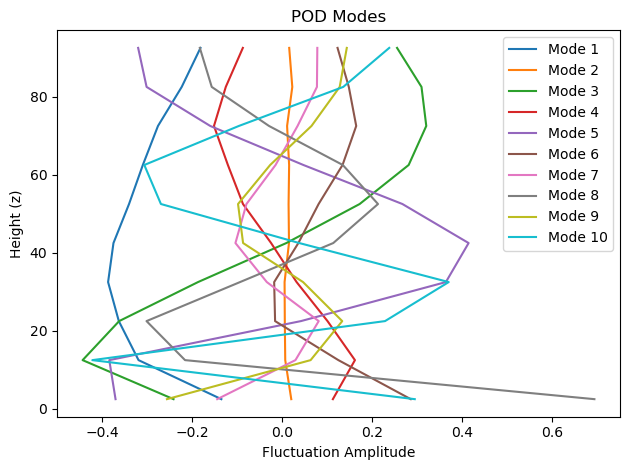

In [10]:
plot_pod_modes(pod_lib['modes'], pod_lib['z_coords'], n_modes=10)

In [11]:
## QUICK GUIDE TO USING THE POD LIBRARY
##
a = pod_lib['coeffs']
phi = pod_lib['modes']
ran_n = np.random.choice(pod_lib['samples'], size=1)[0]
z = 10

# get the first mode's u component at z=10 for the random sample
u_1 = a(ran_n)[0] * phi(z)[0,0]

# get the first mode's full component at z=10 for the random sample
U_1 = a(ran_n)[0] * phi(z)[0]

# get all modes' u component at z=10 for the random sample
u_N = a(ran_n) * phi(z)[:,0]

# get the full fluctuation profile at z=10 for the random sample, all components
U_N = a(ran_n) @ phi(z)

# get the full fluctuation profile across all heights for the random sample
U_N_all = a(ran_n) @ phi(np.arange(10)).reshape(10,13, 3)

print("Single mode, single component at z=10:", u_1.shape)
print("Single mode, all components at z=10:", U_1.shape)
print("Full fluctuation profile at z=10 for random sample:", u_N.shape)
print("Full fluctuation profile at z=10 for random sample, all components:", U_N.shape)
print("Full fluctuation profile across all heights for random sample:", U_N_all.shape)

Single mode, single component at z=10: ()
Single mode, all components at z=10: (3,)
Full fluctuation profile at z=10 for random sample: (13,)
Full fluctuation profile at z=10 for random sample, all components: (3,)
Full fluctuation profile across all heights for random sample: (10, 3)


In [26]:
def plot_scaled_pod(pod_lib, n_modes, wind: WindField, ax=None):
    tke_rans = wind.ds.tke.values
    z_coords = wind.ds.z.values

    phi = pod_lib['modes']
    a = pod_lib['coeffs']

    ran_n = np.random.choice(pod_lib['samples'], size=1)[0]

    tke_pod = np.zeros_like(tke_rans)
    prime = np.zeros((3, len(tke_rans))) # (3, n_z) for broadcasting

    for i, z in enumerate(z_coords):
        raw_prime = a(ran_n)[:n_modes] @ phi(z)[:n_modes] # Use only the selected number of modes
        prime[:, i] = raw_prime
        tke_pod[i] = 0.5 * (raw_prime[0]**2 + raw_prime[1]**2 + raw_prime[2]**2)

    gamma = np.sqrt(tke_rans / tke_pod)
    
    if ax is None:
        ax = plt.gca()

    u = wind.ds.U.values + prime[0] * gamma
    v = wind.ds.V.values + prime[1] * gamma
    w = wind.ds.W.values + prime[2] * gamma

    ax.plot(u, wind.ds.z.values, label='U with POD Fluctuations {0}'.format(n_modes))
    ax.set_xlabel('Wind Speed (m/s)')
    ax.set_ylabel('Height (m)')

Synthesizing wind field with parameters: z_height=100, direction=0, U_ref=6, z0=0.03, z_ref=10


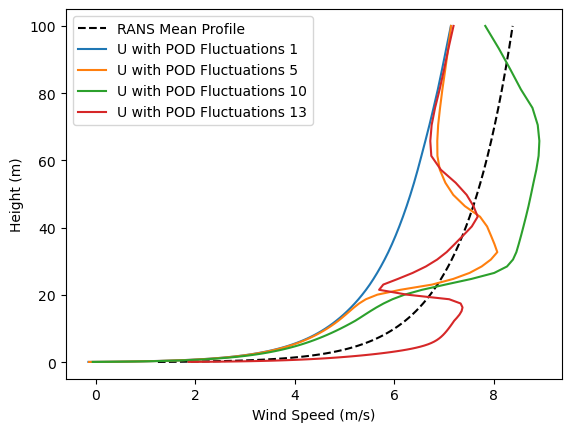

In [31]:
w = WindField(U_ref=6, z_ref=10)
plt.plot(w.ds.U.values, w.ds.z.values, label='RANS Mean Profile', color='k', linestyle='--')
plot_scaled_pod(pod_lib, n_modes=1, wind=w)
plot_scaled_pod(pod_lib, n_modes=5, wind=w)
plot_scaled_pod(pod_lib, n_modes=10, wind=w)
plot_scaled_pod(pod_lib, n_modes=13, wind=w)
plt.legend()

In [ ]:
n_mode = 0
